NAME : VIKAS MALVIYA

SCH. NO. : 25215011109

SUBJECT : LAB 03

TITLE: Gaussian Mixture Models



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture
from matplotlib.patches import Ellipse

np.random.seed(42)


In [ ]:
X, y_true = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=[1.0, 1.2, 0.8],
    random_state=42
)
print("Shape of X:", X.shape)


Shape of X: (300, 2)


In [ ]:
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm.fit(X)

labels = gmm.predict(X)


In [ ]:
def draw_ellipse(position, covariance, ax=None, **kwargs):
    """
    Draw ellipse showing Gaussian covariance.
    position: mean (x, y)
    covariance: 2x2 matrix
    """
    ax = ax or plt.gca()

    eigvals, eigvecs = np.linalg.eigh(covariance)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))

    width, height = 2 * np.sqrt(eigvals)

    for nsig in [1, 2, 3]:
        ell = Ellipse(position, nsig * width, nsig * height, angle=angle, **kwargs)
        ax.add_patch(ell)


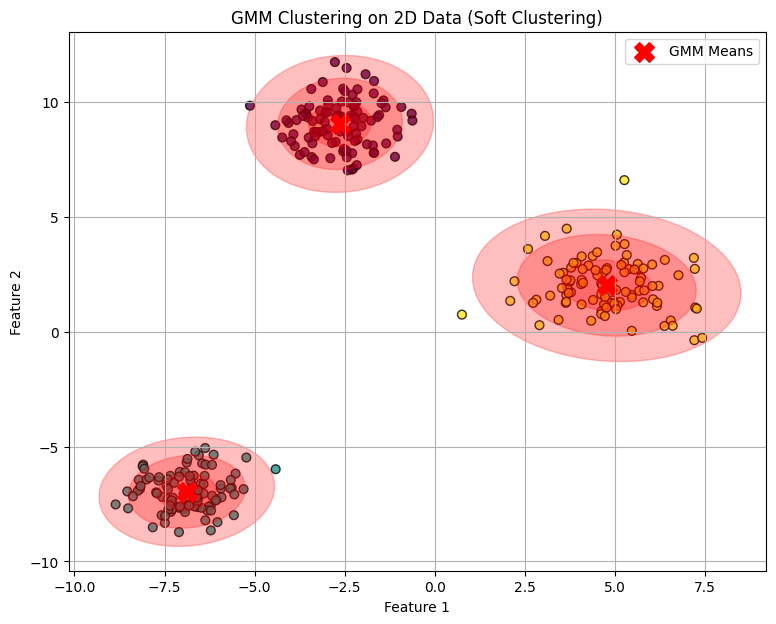

In [ ]:
plt.figure(figsize=(9, 7))
plt.scatter(X[:, 0], X[:, 1], c=labels, s=40, cmap="viridis", edgecolor="black", alpha=0.8)

for mean, cov in zip(gmm.means_, gmm.covariances_):
    draw_ellipse(mean, cov, alpha=0.25, color="red")

plt.scatter(gmm.means_[:, 0], gmm.means_[:, 1], c="red", s=200, marker="X", label="GMM Means")

plt.title("GMM Clustering on 2D Data (Soft Clustering)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
print("\n✅ Converged Means (centers):\n")
print(gmm.means_)

print("\n✅ Covariance Matrices:\n")
for i, cov in enumerate(gmm.covariances_):
    print(f"Component {i+1} Covariance Matrix:\n{cov}\n")



✅ Converged Means (centers):

[[-2.63323268  9.04356978]
 [-6.88302287 -6.96320924]
 [ 4.76854828  2.01807919]]

✅ Covariance Matrices:

Component 1 Covariance Matrix:
[[0.74869031 0.04368399]
 [0.04368399 0.98715159]]

Component 2 Covariance Matrix:
[[0.65895602 0.06127387]
 [0.06127387 0.62897448]]

Component 3 Covariance Matrix:
[[ 1.54128271 -0.14175788]
 [-0.14175788  1.22404827]]

